# Energy Consumption LSTM Modeling

## 목적
- `train.csv`와 `building_info.csv`를 `건물번호` 기준으로 병합
- EDA 결과를 반영해 LSTM 기반 전력소비량 예측 모델 학습
- 스케일링 및 전처리 포함
- 예측 성능은 **RMSE와 그래프**로 확인

## 중요 참고
`test.csv`에는 실제 타깃(`전력소비량(kWh)`)이 없기 때문에,  
**엄밀한 RMSE는 train 내부 validation 구간**(각 건물별 마지막 7일)에서 계산합니다.  
이후 학습된 모델로 `test.csv` 구간은 **예측값 생성**만 수행합니다.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("torch version:", torch.__version__)


torch version: 2.11.0+cu130


In [2]:
# 한글 폰트 설정 (가능한 경우만 적용)
import matplotlib.font_manager as fm

candidate_fonts = [
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
    "/System/Library/Fonts/AppleSDGothicNeo.ttc",
    "/Library/Fonts/AppleGothic.ttf",
    "C:/Windows/Fonts/malgun.ttf",
]

for font_path in candidate_fonts:
    if Path(font_path).exists():
        try:
            fm.fontManager.addfont(font_path)
            font_name = fm.FontProperties(fname=font_path).get_name()
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            print("font loaded:", font_name)
            break
        except:
            pass


font loaded: NanumGothic


In [ ]:
def find_file(filename: str) -> Path:
    candidates = [
        Path.cwd() / filename,
        Path("/mnt/data") / filename,
        Path(filename),
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"{filename} 파일을 찾지 못했습니다.")

train_path = find_file("/home/gean/aiops/AIOps/data/train.csv")
test_path = find_file("/home/gean/aiops/AIOps/data/test.csv")
building_path = find_file("/home/gean/aiops/AIOps/data/building_info.csv")

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
building = pd.read_csv(building_path)

print("train shape   :", train.shape)
print("test shape    :", test.shape)
print("building shape:", building.shape)

train.head()


train shape   : (204000, 10)
test shape    : (16800, 7)
building shape: (100, 7)


,num_date_time,건물번호,일시,기온(°C),강수량(mm),풍속(m/s),습도(%),일조(hr),일사(MJ/m2),전력소비량(kWh)
0,1_20240601 00,1,20240601 00,18.3000,0.0000,2.6000,82.0000,0.0000,0.0000,"5,794.8000"
1,1_20240601 01,1,20240601 01,18.3000,0.0000,2.7000,82.0000,0.0000,0.0000,"5,591.8500"
2,1_20240601 02,1,20240601 02,18.1000,0.0000,2.6000,80.0000,0.0000,0.0000,"5,338.1700"
3,1_20240601 03,1,20240601 03,18.0000,0.0000,2.6000,81.0000,0.0000,0.0000,"4,554.4200"
4,1_20240601 04,1,20240601 04,17.8000,0.0000,1.3000,81.0000,0.0000,0.0000,"3,602.2500"


## 1. building_info 전처리 및 데이터 병합

In [5]:
def preprocess_building_info(building_df: pd.DataFrame) -> pd.DataFrame:
    df = building_df.copy()

    # '-' 처리 후 수치형 변환
    obj_num_cols = ["태양광용량(kW)", "ESS저장용량(kWh)", "PCS용량(kW)"]
    for col in obj_num_cols:
        df[col] = pd.to_numeric(df[col].replace("-", 0), errors="coerce").fillna(0)

    # 파생 변수
    df["냉방면적비율"] = np.where(
        df["연면적(m2)"] > 0,
        df["냉방면적(m2)"] / df["연면적(m2)"],
        0
    )

    df["태양광여부"] = (df["태양광용량(kW)"] > 0).astype(int)
    df["ESS여부"] = (df["ESS저장용량(kWh)"] > 0).astype(int)

    return df

building_pp = preprocess_building_info(building)

train_df = train.merge(building_pp, on="건물번호", how="left")
test_df = test.merge(building_pp, on="건물번호", how="left")

print(train_df.shape, test_df.shape)
train_df.head()


(204000, 19) (16800, 16)


,num_date_time,건물번호,일시,기온(°C),강수량(mm),풍속(m/s),습도(%),일조(hr),일사(MJ/m2),전력소비량(kWh),건물유형,연면적(m2),냉방면적(m2),태양광용량(kW),ESS저장용량(kWh),PCS용량(kW),냉방면적비율,태양광여부,ESS여부
0,1_20240601 00,1,20240601 00,18.3000,0.0000,2.6000,82.0000,0.0000,0.0000,"5,794.8000",호텔,"82,912.7100","77,586.0000",0.0000,0.0000,0,0.9358,0,0
1,1_20240601 01,1,20240601 01,18.3000,0.0000,2.7000,82.0000,0.0000,0.0000,"5,591.8500",호텔,"82,912.7100","77,586.0000",0.0000,0.0000,0,0.9358,0,0
2,1_20240601 02,1,20240601 02,18.1000,0.0000,2.6000,80.0000,0.0000,0.0000,"5,338.1700",호텔,"82,912.7100","77,586.0000",0.0000,0.0000,0,0.9358,0,0
3,1_20240601 03,1,20240601 03,18.0000,0.0000,2.6000,81.0000,0.0000,0.0000,"4,554.4200",호텔,"82,912.7100","77,586.0000",0.0000,0.0000,0,0.9358,0,0
4,1_20240601 04,1,20240601 04,17.8000,0.0000,1.3000,81.0000,0.0000,0.0000,"3,602.2500",호텔,"82,912.7100","77,586.0000",0.0000,0.0000,0,0.9358,0,0


## 2. 시간 변수 생성

In [6]:
def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["datetime"] = pd.to_datetime(out["일시"], format="%Y%m%d %H")
    out["hour"] = out["datetime"].dt.hour
    out["dayofweek"] = out["datetime"].dt.dayofweek
    out["month"] = out["datetime"].dt.month
    out["day"] = out["datetime"].dt.day
    out["is_weekend"] = (out["dayofweek"] >= 5).astype(int)

    # cyclical encoding
    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)
    out["dow_sin"] = np.sin(2 * np.pi * out["dayofweek"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dayofweek"] / 7)
    return out

train_df = add_time_features(train_df)
test_df = add_time_features(test_df)

train_df[["건물번호", "일시", "datetime", "hour", "dayofweek", "month"]].head()


,건물번호,일시,datetime,hour,dayofweek,month
0,1,20240601 00,2024-06-01 00:00:00,0,5,6
1,1,20240601 01,2024-06-01 01:00:00,1,5,6
2,1,20240601 02,2024-06-01 02:00:00,2,5,6
3,1,20240601 03,2024-06-01 03:00:00,3,5,6
4,1,20240601 04,2024-06-01 04:00:00,4,5,6


## 3. 간단 EDA

In [7]:
print("[train info]")
display(train_df.info())

print("\n[결측치 개수]")
display(train_df.isnull().sum().sort_values(ascending=False).head(20))

display(train_df.describe(include="all").T.head(20))


[train info]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204000 entries, 0 to 203999
Data columns (total 29 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   num_date_time  204000 non-null  object        
 1   건물번호           204000 non-null  int64         
 2   일시             204000 non-null  object        
 3   기온(°C)         204000 non-null  float64       
 4   강수량(mm)        204000 non-null  float64       
 5   풍속(m/s)        204000 non-null  float64       
 6   습도(%)          204000 non-null  float64       
 7   일조(hr)         204000 non-null  float64       
 8   일사(MJ/m2)      204000 non-null  float64       
 9   전력소비량(kWh)     204000 non-null  float64       
 10  건물유형           204000 non-null  object        
 11  연면적(m2)        204000 non-null  float64       
 12  냉방면적(m2)       204000 non-null  float64       
 13  태양광용량(kW)      204000 non-null  float64       
 14  ESS저장용량(kWh)   204000 non-null  float64

None


[결측치 개수]


num_date_time    0
건물번호             0
일시               0
기온(°C)           0
강수량(mm)          0
풍속(m/s)          0
습도(%)            0
일조(hr)           0
일사(MJ/m2)        0
전력소비량(kWh)       0
건물유형             0
연면적(m2)          0
냉방면적(m2)         0
태양광용량(kW)        0
ESS저장용량(kWh)     0
PCS용량(kW)        0
냉방면적비율           0
태양광여부            0
ESS여부            0
datetime         0
dtype: int64

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
num_date_time,204000,204000,100_20240824 07,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
건물번호,"204,000.0000",NaN,NaN,NaN,50.5000,1.0000,25.7500,50.5000,75.2500,100.0000,28.8661
일시,204000,2040,20240824 23,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
기온(°C),"204,000.0000",NaN,NaN,NaN,26.0981,8.4000,23.5000,26.3000,28.8000,38.7000,4.0529
강수량(mm),"204,000.0000",NaN,NaN,NaN,0.3042,0.0000,0.0000,0.0000,0.0000,100.9000,2.0529
풍속(m/s),"204,000.0000",NaN,NaN,NaN,1.9680,0.0000,1.0000,1.8000,2.7000,15.2000,1.3161
습도(%),"204,000.0000",NaN,NaN,NaN,75.2067,0.0000,64.0000,78.0000,88.0000,100.0000,16.3785
일조(hr),"204,000.0000",NaN,NaN,NaN,0.2775,0.0000,0.0000,0.0000,0.6000,1.0000,0.3965
일사(MJ/m2),"204,000.0000",NaN,NaN,NaN,0.7028,0.0000,0.0000,0.0500,1.2300,3.9500,1.0174
전력소비량(kWh),"204,000.0000",NaN,NaN,NaN,"3,329.5759",0.0000,"1,176.1200","1,935.7200","3,726.7650","27,155.9400","3,689.1028"


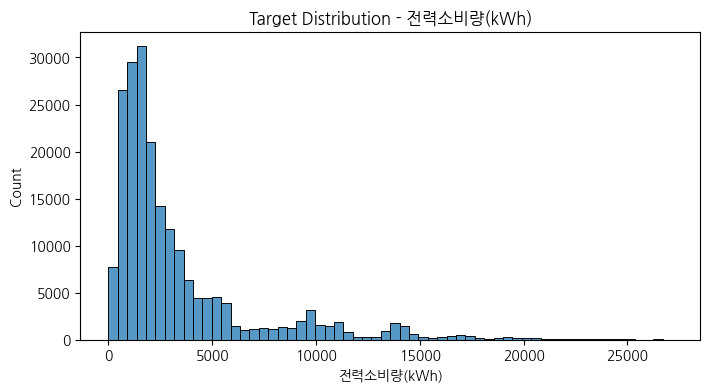

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(train_df["전력소비량(kWh)"], bins=60)
plt.title("Target Distribution - 전력소비량(kWh)")
plt.show()


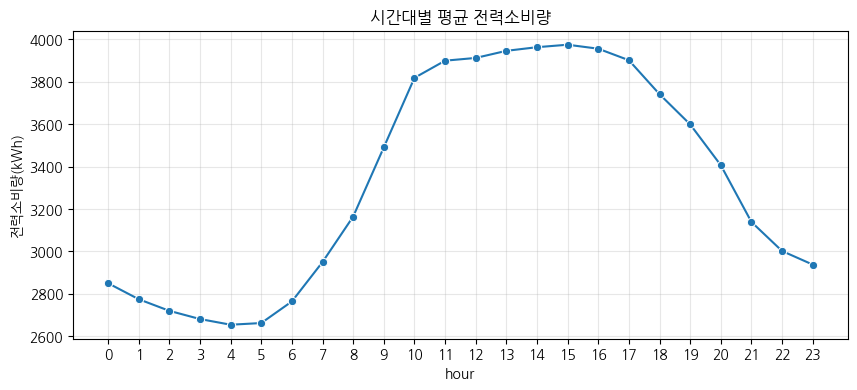

In [9]:
hourly_pattern = (
    train_df.groupby("hour")["전력소비량(kWh)"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 4))
sns.lineplot(data=hourly_pattern, x="hour", y="전력소비량(kWh)", marker="o")
plt.title("시간대별 평균 전력소비량")
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.show()


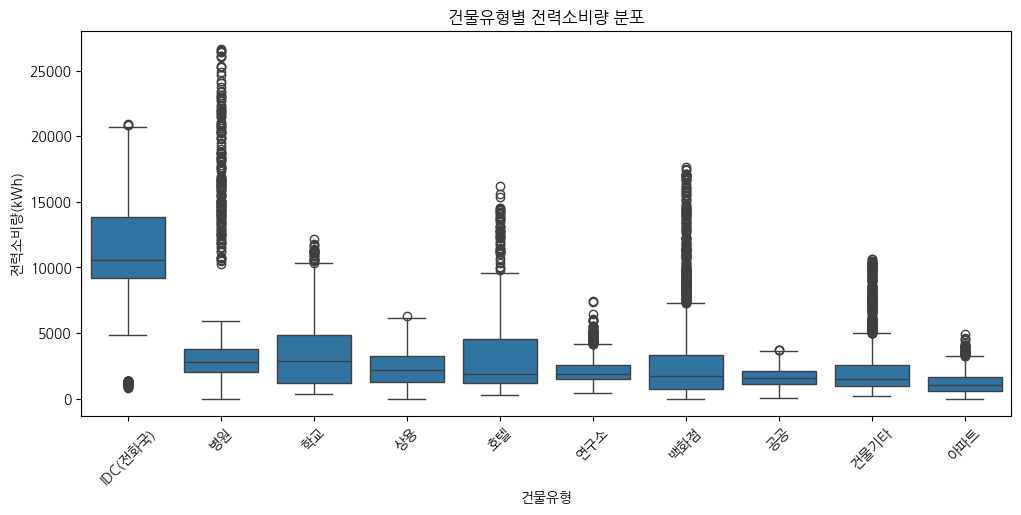

In [10]:
plt.figure(figsize=(12, 5))
building_order = (
    train_df.groupby("건물유형")["전력소비량(kWh)"]
    .median()
    .sort_values(ascending=False)
    .index
)
sns.boxplot(
    data=train_df.sample(min(20000, len(train_df)), random_state=42),
    x="건물유형",
    y="전력소비량(kWh)",
    order=building_order
)
plt.title("건물유형별 전력소비량 분포")
plt.xticks(rotation=45)
plt.show()


## 4. 모델링 전략

이번 노트북에서는 다음 방식으로 LSTM을 구성합니다.

- 입력 데이터: 날씨 변수 + 시간 변수 + 건물 정적 정보
- 추가 특징: 직전 시점 전력소비량(`lag1_kwh`)
- 시퀀스 길이: 최근 `24시간`
- Validation: 각 건물별 **마지막 7일(168시간)** 구간
- 평가 지표: Validation RMSE
- Test 예측: train 마지막 구간을 이용해 **재귀적(autoregressive)** 예측


In [11]:
# 건물유형 원-핫 인코딩용 컬럼 정렬
all_building_types = sorted(train_df["건물유형"].dropna().unique().tolist())

def add_building_dummies(df: pd.DataFrame, categories: list) -> pd.DataFrame:
    out = df.copy()
    cat = pd.Categorical(out["건물유형"], categories=categories)
    dummies = pd.get_dummies(cat, prefix="건물유형")
    out = pd.concat([out, dummies], axis=1)
    return out

train_df = add_building_dummies(train_df, all_building_types)
test_df = add_building_dummies(test_df, all_building_types)

dummy_cols = [c for c in train_df.columns if c.startswith("건물유형_")]

feature_cols = [
    "기온(°C)", "강수량(mm)", "풍속(m/s)", "습도(%)",
    "연면적(m2)", "냉방면적(m2)", "태양광용량(kW)", "ESS저장용량(kWh)", "PCS용량(kW)",
    "냉방면적비율", "태양광여부", "ESS여부",
    "hour", "dayofweek", "month", "day", "is_weekend",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
] + dummy_cols

target_col = "전력소비량(kWh)"
seq_len = 24
val_hours = 24 * 7

feature_cols


['기온(°C)',
 '강수량(mm)',
 '풍속(m/s)',
 '습도(%)',
 '연면적(m2)',
 '냉방면적(m2)',
 '태양광용량(kW)',
 'ESS저장용량(kWh)',
 'PCS용량(kW)',
 '냉방면적비율',
 '태양광여부',
 'ESS여부',
 'hour',
 'dayofweek',
 'month',
 'day',
 'is_weekend',
 'hour_sin',
 'hour_cos',
 'dow_sin',
 'dow_cos',
 '건물유형_IDC(전화국)',
 '건물유형_건물기타',
 '건물유형_공공',
 '건물유형_백화점',
 '건물유형_병원',
 '건물유형_상용',
 '건물유형_아파트',
 '건물유형_연구소',
 '건물유형_학교',
 '건물유형_호텔']

In [12]:
# 결측치 처리
for col in feature_cols:
    if train_df[col].dtype == bool:
        train_df[col] = train_df[col].astype(int)
        test_df[col] = test_df[col].astype(int)

    fill_value = train_df[col].median() if pd.api.types.is_numeric_dtype(train_df[col]) else 0
    train_df[col] = train_df[col].fillna(fill_value)
    test_df[col] = test_df[col].fillna(fill_value)

train_df = train_df.sort_values(["건물번호", "datetime"]).reset_index(drop=True)
test_df = test_df.sort_values(["건물번호", "datetime"]).reset_index(drop=True)

# lag1 생성
train_df["lag1_kwh"] = train_df.groupby("건물번호")[target_col].shift(1)

# 각 건물의 첫 시점은 해당 건물의 중앙값으로 보정
building_median = train_df.groupby("건물번호")[target_col].transform("median")
train_df["lag1_kwh"] = train_df["lag1_kwh"].fillna(building_median)

# validation: 각 건물별 마지막 7일
train_df["is_valid"] = train_df.groupby("건물번호").cumcount(ascending=False) < val_hours

print(train_df["is_valid"].value_counts())
train_df.head()


is_valid
False    187200
True      16800
Name: count, dtype: int64


,num_date_time,건물번호,일시,기온(°C),강수량(mm),풍속(m/s),습도(%),일조(hr),일사(MJ/m2),전력소비량(kWh),건물유형,연면적(m2),냉방면적(m2),태양광용량(kW),ESS저장용량(kWh),PCS용량(kW),냉방면적비율,태양광여부,ESS여부,datetime,hour,dayofweek,month,day,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,건물유형_IDC(전화국),건물유형_건물기타,건물유형_공공,건물유형_백화점,건물유형_병원,건물유형_상용,건물유형_아파트,건물유형_연구소,건물유형_학교,건물유형_호텔,lag1_kwh,is_valid
0,1_20240601 00,1,20240601 00,18.3000,0.0000,2.6000,82.0000,0.0000,0.0000,"5,794.8000",호텔,"82,912.7100","77,586.0000",0.0000,0.0000,0,0.9358,0,0,2024-06-01 00:00:00,0,5,6,1,1,0.0000,1.0000,-0.9749,-0.2225,0,0,0,0,0,0,0,0,0,1,"5,326.0500",False
1,1_20240601 01,1,20240601 01,18.3000,0.0000,2.7000,82.0000,0.0000,0.0000,"5,591.8500",호텔,"82,912.7100","77,586.0000",0.0000,0.0000,0,0.9358,0,0,2024-06-01 01:00:00,1,5,6,1,1,0.2588,0.9659,-0.9749,-0.2225,0,0,0,0,0,0,0,0,0,1,"5,794.8000",False
2,1_20240601 02,1,20240601 02,18.1000,0.0000,2.6000,80.0000,0.0000,0.0000,"5,338.1700",호텔,"82,912.7100","77,586.0000",0.0000,0.0000,0,0.9358,0,0,2024-06-01 02:00:00,2,5,6,1,1,0.5000,0.8660,-0.9749,-0.2225,0,0,0,0,0,0,0,0,0,1,"5,591.8500",False
3,1_20240601 03,1,20240601 03,18.0000,0.0000,2.6000,81.0000,0.0000,0.0000,"4,554.4200",호텔,"82,912.7100","77,586.0000",0.0000,0.0000,0,0.9358,0,0,2024-06-01 03:00:00,3,5,6,1,1,0.7071,0.7071,-0.9749,-0.2225,0,0,0,0,0,0,0,0,0,1,"5,338.1700",False
4,1_20240601 04,1,20240601 04,17.8000,0.0000,1.3000,81.0000,0.0000,0.0000,"3,602.2500",호텔,"82,912.7100","77,586.0000",0.0000,0.0000,0,0.9358,0,0,2024-06-01 04:00:00,4,5,6,1,1,0.8660,0.5000,-0.9749,-0.2225,0,0,0,0,0,0,0,0,0,1,"4,554.4200",False


In [13]:
# 스케일러 학습은 validation 제외한 train 구간에서만
train_only_df = train_df.loc[~train_df["is_valid"]].copy()
valid_only_df = train_df.loc[train_df["is_valid"]].copy()

scale_feature_cols = feature_cols + ["lag1_kwh"]

feature_scaler = StandardScaler()
target_scaler = StandardScaler()

feature_scaler.fit(train_only_df[scale_feature_cols])
target_scaler.fit(train_only_df[[target_col]])

for df in [train_df, train_only_df, valid_only_df]:
    df[scale_feature_cols] = feature_scaler.transform(df[scale_feature_cols])
    df["target_scaled"] = target_scaler.transform(df[[target_col]])

print("train_only:", train_only_df.shape)
print("valid_only:", valid_only_df.shape)


train_only: (187200, 42)
valid_only: (16800, 42)


In [14]:
def make_sequence_data(df: pd.DataFrame, seq_len: int, feature_cols: list):
    xs, ys, meta = [], [], []

    for bno, g in df.groupby("건물번호"):
        g = g.sort_values("datetime").reset_index(drop=True)

        for i in range(seq_len - 1, len(g)):
            x_seq = g.loc[i-seq_len+1:i, feature_cols].to_numpy(dtype=np.float32)
            y_val = np.float32(g.loc[i, "target_scaled"])

            xs.append(x_seq)
            ys.append(y_val)
            meta.append({
                "건물번호": bno,
                "datetime": g.loc[i, "datetime"],
                "is_valid": int(g.loc[i, "is_valid"]),
                "actual_kwh": g.loc[i, target_col]
            })

    return np.stack(xs), np.array(ys), pd.DataFrame(meta)

X_all, y_all, meta_all = make_sequence_data(
    train_df,
    seq_len=seq_len,
    feature_cols=scale_feature_cols
)

train_mask = meta_all["is_valid"] == 0
valid_mask = meta_all["is_valid"] == 1

X_train = X_all[train_mask.values]
y_train = y_all[train_mask.values]
X_valid = X_all[valid_mask.values]
y_valid = y_all[valid_mask.values]
meta_valid = meta_all.loc[valid_mask].reset_index(drop=True)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_valid:", X_valid.shape, "y_valid:", y_valid.shape)
meta_valid.head()


X_train: (184900, 24, 32) y_train: (184900,)
X_valid: (16800, 24, 32) y_valid: (16800,)


,건물번호,datetime,is_valid,actual_kwh
0,1,2024-08-18 00:00:00,1,"4,036.3800"
1,1,2024-08-18 01:00:00,1,"3,923.4300"
2,1,2024-08-18 02:00:00,1,"3,917.1000"
3,1,2024-08-18 03:00:00,1,"3,875.8800"
4,1,2024-08-18 04:00:00,1,"4,023.4800"


In [15]:
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 256

train_ds = SequenceDataset(X_train, y_train)
valid_ds = SequenceDataset(X_valid, y_valid)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

len(train_ds), len(valid_ds)


(184900, 16800)

## 5. PyTorch LSTM 모델 정의 및 학습

In [16]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        pred = self.fc(last_hidden).squeeze(-1)
        return pred

device = "cuda" if torch.cuda.is_available() else "cpu"
model = LSTMRegressor(input_dim=len(scale_feature_cols)).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("device:", device)
print(model)


device: cpu
LSTMRegressor(
  (lstm): LSTM(32, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [17]:
def evaluate(model, loader, criterion, device):
    model.eval()
    losses = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            losses.append(loss.item())

    return float(np.mean(losses))

epochs = 15
best_valid_loss = np.inf
best_state = None
patience = 4
patience_count = 0

history = {
    "train_loss": [],
    "valid_loss": []
}

for epoch in range(1, epochs + 1):
    model.train()
    train_losses = []

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))
    valid_loss = evaluate(model, valid_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)

    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.6f} | Valid Loss: {valid_loss:.6f}")

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_state = model.state_dict()
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= patience:
            print("Early stopping triggered.")
            break

model.load_state_dict(best_state)


Epoch 01 | Train Loss: 0.064792 | Valid Loss: 0.015515
Epoch 02 | Train Loss: 0.021710 | Valid Loss: 0.008896
Epoch 03 | Train Loss: 0.018126 | Valid Loss: 0.008143
Epoch 04 | Train Loss: 0.016265 | Valid Loss: 0.006512
Epoch 05 | Train Loss: 0.015031 | Valid Loss: 0.005422
Epoch 06 | Train Loss: 0.014239 | Valid Loss: 0.005905
Epoch 07 | Train Loss: 0.013556 | Valid Loss: 0.004265
Epoch 08 | Train Loss: 0.013046 | Valid Loss: 0.004705
Epoch 09 | Train Loss: 0.012923 | Valid Loss: 0.004448
Epoch 10 | Train Loss: 0.012601 | Valid Loss: 0.004071
Epoch 11 | Train Loss: 0.012632 | Valid Loss: 0.005890
Epoch 12 | Train Loss: 0.012693 | Valid Loss: 0.005022
Epoch 13 | Train Loss: 0.012415 | Valid Loss: 0.004520
Epoch 14 | Train Loss: 0.012317 | Valid Loss: 0.004225
Early stopping triggered.


<All keys matched successfully>

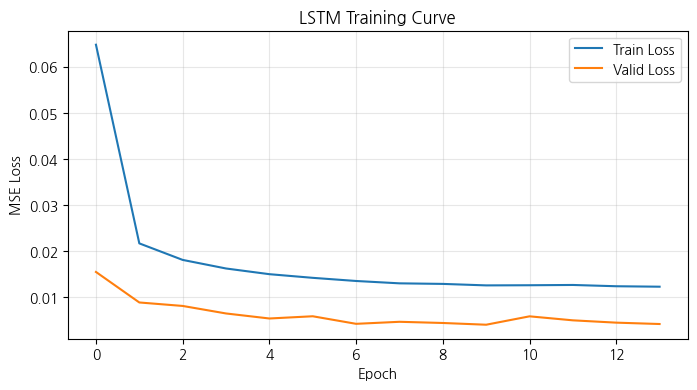

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["valid_loss"], label="Valid Loss")
plt.title("LSTM Training Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 6. Validation RMSE 평가

In [19]:
model.eval()

valid_preds_scaled = []
with torch.no_grad():
    for X_batch, _ in valid_loader:
        X_batch = X_batch.to(device)
        pred = model(X_batch).detach().cpu().numpy()
        valid_preds_scaled.append(pred)

valid_preds_scaled = np.concatenate(valid_preds_scaled).reshape(-1, 1)
valid_true_scaled = y_valid.reshape(-1, 1)

valid_preds = target_scaler.inverse_transform(valid_preds_scaled).reshape(-1)
valid_true = target_scaler.inverse_transform(valid_true_scaled).reshape(-1)

valid_rmse = np.sqrt(mean_squared_error(valid_true, valid_preds))
print(f"Validation RMSE: {valid_rmse:,.4f}")


Validation RMSE: 238.0333


In [20]:
valid_result = meta_valid.copy()
valid_result["actual_kwh"] = valid_true
valid_result["pred_kwh"] = valid_preds
valid_result["error"] = valid_result["actual_kwh"] - valid_result["pred_kwh"]

valid_result.head()


,건물번호,datetime,is_valid,actual_kwh,pred_kwh,error
0,1,2024-08-18 00:00:00,1,"4,036.3799","4,127.9492",-91.5693
1,1,2024-08-18 01:00:00,1,"3,923.4299","3,698.4617",224.9683
2,1,2024-08-18 02:00:00,1,"3,917.1001","3,648.3687",268.7314
3,1,2024-08-18 03:00:00,1,"3,875.8799","3,663.7793",212.1006
4,1,2024-08-18 04:00:00,1,"4,023.4800","3,689.3430",334.1370


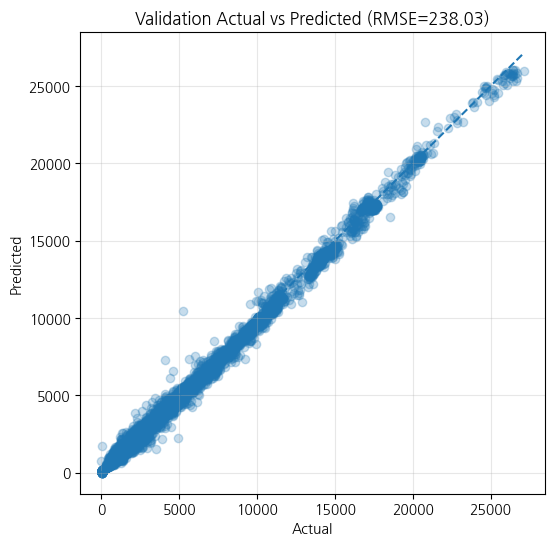

In [21]:
# 전체 산점도
plt.figure(figsize=(6, 6))
plt.scatter(valid_result["actual_kwh"], valid_result["pred_kwh"], alpha=0.25)
mn = min(valid_result["actual_kwh"].min(), valid_result["pred_kwh"].min())
mx = max(valid_result["actual_kwh"].max(), valid_result["pred_kwh"].max())
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Validation Actual vs Predicted (RMSE={valid_rmse:,.2f})")
plt.grid(alpha=0.3)
plt.show()


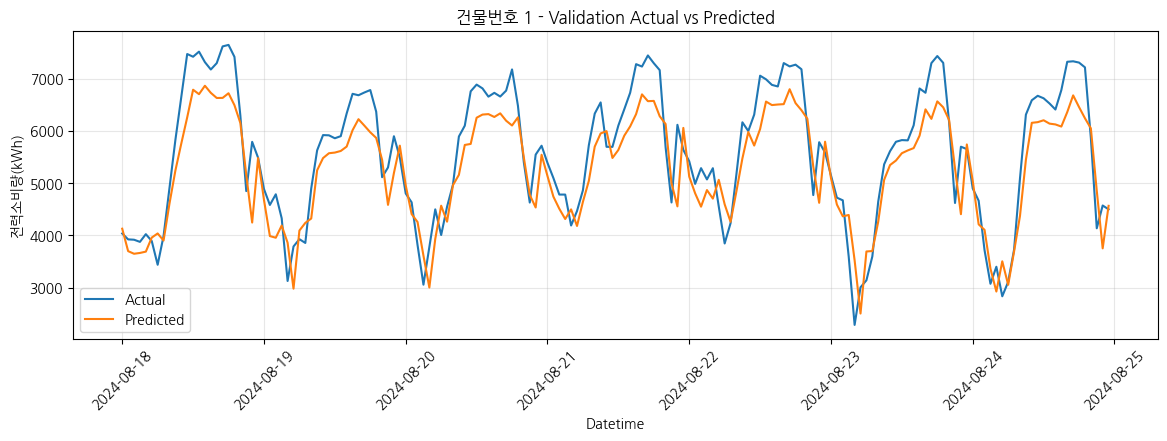

In [22]:
# 특정 건물의 시계열 비교 그래프
sample_building = int(valid_result["건물번호"].mode().iloc[0])

plot_df = (
    valid_result[valid_result["건물번호"] == sample_building]
    .sort_values("datetime")
    .reset_index(drop=True)
)

plt.figure(figsize=(14, 4))
plt.plot(plot_df["datetime"], plot_df["actual_kwh"], label="Actual")
plt.plot(plot_df["datetime"], plot_df["pred_kwh"], label="Predicted")
plt.title(f"건물번호 {sample_building} - Validation Actual vs Predicted")
plt.xlabel("Datetime")
plt.ylabel("전력소비량(kWh)")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.show()
